# 04_Stress Test et Synthèse
Projet : Credit Risk Scoring (Lending Club)

## Pourquoi un stress test ?

Jusqu'ici, on a mesuré une perte attendue (EL) **dans des conditions normales**, celles observées historiquement dans le dataset. Mais une banque doit aussi
répondre à une question différente : **"Que se passe-t-il si la conjoncture
se dégrade ?"** (récession, hausse du chômage, choc de taux...).

C'est le rôle du stress test : simuler un scénario économique défavorable et
mesurer l'impact sur les pertes du portefeuille. Les régulateurs bancaires
l'exigent sous des formes très encadrées (CCAR aux États-Unis, stress tests
EBA en Europe), avec des scénarios macroéconomiques complexes et des modèles
satellites reliant PIB/chômage/taux à la probabilité de défaut.

**Ce notebook n'est pas un stress test réglementaire.** C'est une démonstration
simplifiée de sensibilité : on applique un choc arbitraire mais raisonnable à
la PD, et on observe comment l'EL réagit. L'objectif est de montrer qu'on
comprend le principe et qu'on peut le mettre en œuvre, pas de reproduire un
modèle CCAR/EBA complet, ce point est explicitement assumé comme limite.

## Ce qui est fait
1. Définir un scénario de choc macroéconomique simplifié sur la PD
2. Recalculer l'EL sous ce scénario et la comparer à l'EL de base
3. Visualiser la sensibilité par segment de risque
4. Traduire les résultats en recommandations d'octroi concrètes
5. Synthétiser les limites de l'ensemble du projet

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

## 1. Chargement des données

On repart du portefeuille test enrichi au notebook 03 : PD prédite, LGD
prédite, EAD estimée, EL de base déjà calculée.

In [2]:
test = pd.read_parquet("../data/processed/test_with_el.parquet")
print(f"Portefeuille test : {test.shape[0]:,} prêts".replace(",", " "))
print(f"EL de base (portefeuille total) : {test['expected_loss'].sum():,.0f} $".replace(",", " "))

Portefeuille test : 169 321 prêts
EL de base (portefeuille total) : 363 312 095 $


## 2. Définition du scénario de choc

**Principe retenu** : un choc macroéconomique dégrade la PD de tous les
emprunteurs, mais **pas uniformément**. En pratique, les segments déjà les
plus fragiles (grades les plus risqués) sont ceux qui encaissent le plus fort
le premier coup d'une récession (perte d'emploi, resserrement du crédit),
alors que les meilleurs profils (grade A) sont plus résilients.

**Scénario retenu (hypothèse de travail, non calibrée sur une récession
historique réelle)** :

| Grade | Choc appliqué sur la PD |
|---|---|
| A, B, C | +3 points de pourcentage |
| D, E | +7 points de pourcentage |
| F, G | +12 points de pourcentage |

La PD choquée est plafonnée à 100% (une probabilité ne peut jamais dépasser 1).
Ce choix de différenciation par grade est **documenté explicitement comme une
hypothèse de démonstration**, pas comme un paramètre calibré empiriquement.
Un vrai stress test réglementaire dériverait ce choc d'un modèle satellite
reliant PIB/chômage aux taux de défaut historiques par segment.

In [3]:
shock_map = {
    "A": 0.03, "B": 0.03, "C": 0.03,
    "D": 0.07, "E": 0.07,
    "F": 0.12, "G": 0.12,
}

test["pd_shock"] = test["grade"].map(shock_map)
test["pd_pred_stress"] = (test["pd_pred"] + test["pd_shock"]).clip(upper=1.0)

print("Vérification du choc appliqué par grade :")
test.groupby("grade", observed=True)[["pd_pred", "pd_pred_stress"]].mean().round(4)

Vérification du choc appliqué par grade :


,pd_pred,pd_pred_stress
grade,,
A,0.0557,0.0857
B,0.1344,0.1644
C,0.2300,0.2600
D,0.3093,0.3793
E,0.4116,0.4816
F,0.5138,0.6338
G,0.5291,0.6491


## 3. Perte attendue sous stress

On recalcule l'EL avec la PD choquée, en gardant LGD et EAD identiques Un
choc macro dégrade d'abord la probabilité de défaut ; modéliser son impact sur
la LGD (moins de recouvrement en récession) serait une extension légitime mais
hors du périmètre assumé de ce projet (mentionné dans les limites).

In [4]:
test["expected_loss_stress"] = test["pd_pred_stress"] * test["lgd_pred"] * test["ead_estimate"]

el_base = test["expected_loss"].sum()
el_stress = test["expected_loss_stress"].sum()
increase_pct = (el_stress - el_base) / el_base

print(f"EL de base (scénario normal)     : {el_base:,.0f} $".replace(",", " "))
print(f"EL sous stress (scénario dégradé) : {el_stress:,.0f} $".replace(",", " "))
print(f"Augmentation de la perte attendue : {increase_pct:.1%}")
print(f"Surcroît de perte en valeur absolue : {el_stress - el_base:,.0f} $".replace(",", " "))

EL de base (scénario normal)     : 363 312 095 $
EL sous stress (scénario dégradé) : 431 421 960 $
Augmentation de la perte attendue : 18.7%
Surcroît de perte en valeur absolue : 68 109 864 $


## 4. Sensibilité par segment

Visualiser où le choc frappe le plus fort, essentiel pour qu'un comité des
risques sache où concentrer son attention (allocation de capital, ajustement
des politiques d'octroi).

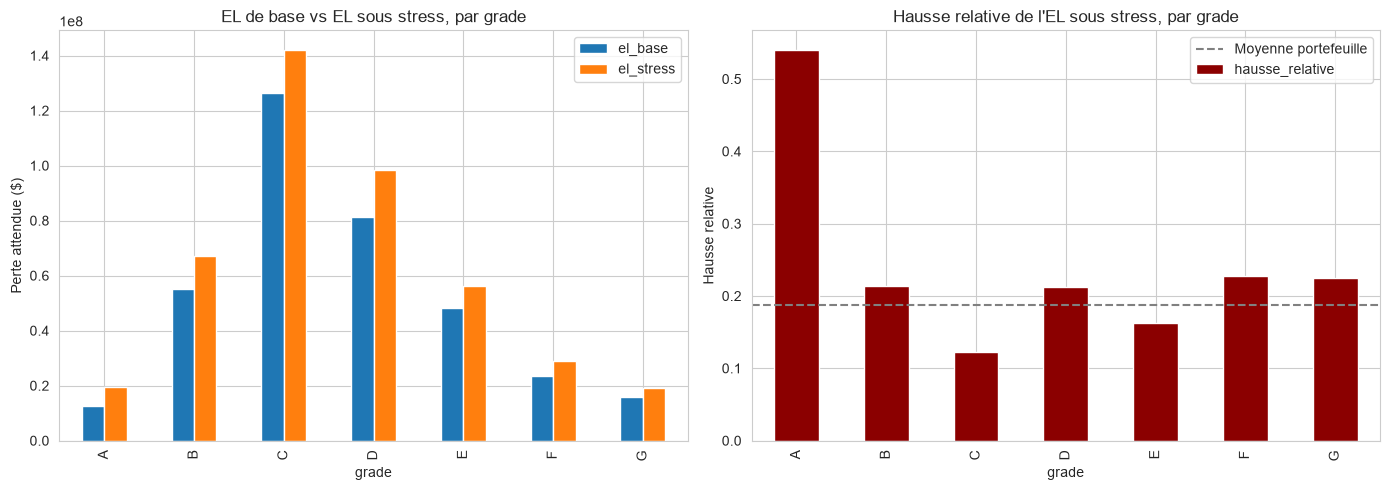

,el_base,el_stress,hausse_relative
grade,,,
A,12552381.0,19331088.0,0.540034
B,55265837.0,67055383.0,0.213324
C,126496080.0,142007878.0,0.122627
D,81278658.0,98550276.0,0.212499
E,48387456.0,56228365.0,0.162044
F,23618896.0,29002715.0,0.227945
G,15712788.0,19246255.0,0.224878


In [5]:
sensitivity = test.groupby("grade", observed=True).agg(
    el_base=("expected_loss", "sum"),
    el_stress=("expected_loss_stress", "sum"),
).round(0)
sensitivity["hausse_relative"] = (sensitivity["el_stress"] - sensitivity["el_base"]) / sensitivity["el_base"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sensitivity[["el_base", "el_stress"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("EL de base vs EL sous stress, par grade")
axes[0].set_ylabel("Perte attendue ($)")

sensitivity["hausse_relative"].plot(kind="bar", ax=axes[1], color="darkred")
axes[1].set_title("Hausse relative de l'EL sous stress, par grade")
axes[1].set_ylabel("Hausse relative")
axes[1].axhline(increase_pct, linestyle="--", color="gray", label="Moyenne portefeuille")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/04_stress_sensitivity.png", dpi=150)
plt.show()

sensitivity

## 5. Cadrage capital : combien la banque doit-elle provisionner en plus ?

In [6]:
total_portfolio = test["funded_amnt"].sum()

print(f"Montant total du portefeuille test        : {total_portfolio:,.0f} $".replace(",", " "))
print(f"EL de base en % du portefeuille            : {el_base / total_portfolio:.2%}")
print(f"EL sous stress en % du portefeuille         : {el_stress / total_portfolio:.2%}")
print(f"Provision supplémentaire nécessaire         : {el_stress - el_base:,.0f} $ "
      f"(+{(el_stress - el_base) / total_portfolio:.2%} du portefeuille)".replace(",", " "))

Montant total du portefeuille test        : 2 421 502 464 $
EL de base en % du portefeuille            : 15.00%
EL sous stress en % du portefeuille         : 17.82%
Provision supplémentaire nécessaire         : 68 109 864 $ (+2.81% du portefeuille)


Sous ce scénario dégradé, la banque devrait immobiliser un montant supplémentaire de capital équivalent au surcroît de perte attendue, soit environ **68,1 millions de dollars** (représentant une hausse de **+2,81%** sur le portefeuille total), pour rester solvable si le scénario se matérialise.

## 6. Recommandations d'octroi par segment de risque

On traduit l'EL de base en un ratio **EL / montant prêté** par prêt, une
mesure directement comparable au taux d'intérêt facturé. Si ce ratio dépasse
la marge que rapporte le prêt, le prêt est structurellement perdant pour la
banque, indépendamment de tout ce qui a été fait jusqu'ici.

In [7]:
test["el_ratio"] = test["expected_loss"] / test["loan_amnt"]

reco = test.groupby("grade", observed=True).agg(
    el_ratio_moyen=("el_ratio", "mean"),
    taux_interet_moyen=("int_rate", "mean"),
    n_prets=("loan_amnt", "count"),
).round(4)
reco["marge_apparente"] = reco["taux_interet_moyen"] / 100 - reco["el_ratio_moyen"]

print("EL/montant prêté comparé au taux d'intérêt facturé, par grade :")
reco

EL/montant prêté comparé au taux d'intérêt facturé, par grade :


,el_ratio_moyen,taux_interet_moyen,n_prets,marge_apparente
grade,,,,
A,0.0362,6.993900,26890,0.033739
B,0.0860,10.596000,47001,0.019960
C,0.1481,14.272200,54919,-0.005378
D,0.1994,18.760799,24521,-0.011792
E,0.2634,24.710400,10214,-0.016296
F,0.3292,29.775900,3649,-0.031441
G,0.3500,30.882099,2127,-0.041179


**Lecture** : une marge apparente positive indique que le taux d'intérêt facturé sur le segment couvre en moyenne la perte attendue (avant coûts opérationnels et coût du capital). Une marge négative signale un segment structurellement sous-tarifé par rapport au risque qu'il porte.

**Recommandation opérationnelle** : 
- Les grades **A et B** dégagent des marges apparentes positives (respectivement +3,37% et +1,99%).
- À partir du **grade C et au-delà (D, E, F, G)**, les marges basculent dans le négatif (allant de -0,5% pour le grade C à plus de -4,1% pour le grade G). 
- Ces segments à risque (C à G) génèrent des pertes qui ne sont plus couvertes par leurs seuls taux d'intérêts. Ce sont donc les candidats prioritaires à un resserrement strict des critères d'octroi ou à une hausse tarifaire importante, d'autant plus que ce sont eux qui verront leur EL exploser en cas de crise macro-économique.

## 7. Limites du projet (synthèse globale)

- **Biais de sélection** : le dataset ne contient que des prêts déjà accordés par Lending Club — aucune information sur les emprunteurs refusés. Le modèle ne peut donc pas apprendre à mieux distinguer les cas limites qui auraient été rejetés à l'octroi.
- **Censure à droite sur les cohortes récentes** : confirmée empiriquement au notebook 01 (taux de défaut du test 2017 supérieur à celui du train).
- **Stress test simplifié** : choc arbitraire sur la PD, non calibré sur une récession historique réelle, et n'intégrant pas l'impact croisé d'une récession sur la LGD (le recouvrement est mécaniquement plus difficile en période de ralentissement économique).
- **Stabilité temporelle non testée** : le modèle n'a pas été validé sur des données postérieures à 2017 (fin du dataset), sa performance sur des cohortes macro-économiques de la décennie suivante reste donc à valider.

## 8. Sauvegarde des résultats finaux

In [8]:
test.to_parquet("../data/processed/test_final_with_stress.parquet", index=False)

summary_final = pd.DataFrame({
    "Métrique": [
        "EL de base (portefeuille test)",
        "EL sous stress",
        "Hausse de l'EL sous stress",
        "EL de base en % du portefeuille",
        "EL sous stress en % du portefeuille",
    ],
    "Valeur": [
        f"{el_base:,.0f} $".replace(",", " "),
        f"{el_stress:,.0f} $".replace(",", " "),
        f"{increase_pct:.1%}",
        f"{el_base / total_portfolio:.2%}",
        f"{el_stress / total_portfolio:.2%}",
    ],
})
summary_final.to_csv("../reports/summary_final_metrics.csv", index=False)

print("Fichiers sauvegardés : test_final_with_stress.parquet, summary_final_metrics.csv")
summary_final

Fichiers sauvegardés : test_final_with_stress.parquet, summary_final_metrics.csv


,Métrique,Valeur
0,EL de base (portefeuille test),363 312 095 $
1,EL sous stress,431 421 960 $
2,Hausse de l'EL sous stress,18.7%
3,EL de base en % du portefeuille,15.00%
4,EL sous stress en % du portefeuille,17.82%
